# SLEEP HEALTH & LIFESTYLE ANALYSIS - WELLNESS ANALYTICS

## Dataset: Sleep Health and Lifestyle Dataset
**Kaynak:** https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

## Proje Hedefi: UYKU KALITESI & YASAM TARZI ANALIZI

## Proje Ozellikleri:
- **Sleep Quality Analysis** - Duration, quality patterns
- **Lifestyle Impact** - Activity, stress, sleep relationship
- **Health Metrics** - BMI, BP, heart rate correlation
- **Sleep Disorder Prediction** - Classification models
- **15+ ML Models** - Neural Network instead of SVM!
- **Wellness Recommendations** - Health insights
- **30+ Visualizations** - Health-focused graphs

## OZEL: Neural Network (MLP) kullanilacak - SVM yerine!

## Proje Adimlari:
1. Veri Yukleme & Health Structure
2. **SLEEP HEALTH EDA** (20+ graphs)
3. **LIFESTYLE ANALYSIS** (Activity, stress)
4. **HEALTH METRICS** (BMI, BP, HR)
5. Feature Engineering (Health-specific)
6. **15+ ML MODELS** (with Neural Network!)
7. **COMPREHENSIVE COMPARISON**
8. Health Insights & Recommendations

## 1. KUTUPHANELER

In [2]:
# Install missing libraries
!pip install catboost

# Temel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sistem
import os
import subprocess
import zipfile
import glob

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE

# Classification Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier,
    VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier  # NEURAL NETWORK - SVM yerine!
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Plotly
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY = True
except:
    PLOTLY = False

# Viz
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('='*80)
print('SLEEP HEALTH & LIFESTYLE - KUTUPHANELER YUKLENDI!')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Plotly: {"Available" if PLOTLY else "Not Available"}')
print('\nOZEL: Neural Network (MLP) kullanilacak - SVM YERINE!')
print('='*80)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00
SLEEP HEALTH & LIFESTYLE - KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2
Plotly: Available

OZEL: Neural Network (MLP) kullanilacak - SVM YERINE!


## 2. VERI YUKLEME

In [3]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"Indiriliyor: {zip_filename}")
    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [4]:
dataset_folder = "sleep_health_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/uom190346a/sleep-health-and-lifestyle-dataset",
    "folder": dataset_folder,
    "zip_filename": "sleep-health.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset mevcut!")

Indiriliyor: sleep-health.zip


In [5]:
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[0])

    print('='*80)
    print('VERI YUKLENDI!')
    print('='*80)
    print(f'Toplam Kayit: {len(df):,}')
    print(f'Sutun Sayisi: {len(df.columns)}')
    print(f'Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*80)
else:
    print('CSV bulunamadi!')

VERI YUKLENDI!
Toplam Kayit: 374
Sutun Sayisi: 13
Bellek: 0.12 MB


In [6]:
print('ILK 10 KAYIT:')
df.head(10)

ILK 10 KAYIT:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.10,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.20,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.90,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.90,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.30,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.80,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.80,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.80,7,75,6,Normal,120/80,70,8000,NaN


In [7]:
print('VERI YAPISI:')
print('='*80)
df.info()

VERI YAPISI:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [8]:
print('SUTUNLAR:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2d}. {col}')

SUTUNLAR:
 1. Person ID
 2. Gender
 3. Age
 4. Occupation
 5. Sleep Duration
 6. Quality of Sleep
 7. Physical Activity Level
 8. Stress Level
 9. BMI Category
10. Blood Pressure
11. Heart Rate
12. Daily Steps
13. Sleep Disorder


In [9]:
print('ISTATISTIKSEL OZET:')
print('='*80)
df.describe(include='all').T

ISTATISTIKSEL OZET:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Person ID,374.00,NaN,NaN,NaN,187.50,108.11,1.00,94.25,187.50,280.75,374.00
Gender,374,2,Male,189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,374.00,NaN,NaN,NaN,42.18,8.67,27.00,35.25,43.00,50.00,59.00
Occupation,374,11,Nurse,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep Duration,374.00,NaN,NaN,NaN,7.13,0.80,5.80,6.40,7.20,7.80,8.50
Quality of Sleep,374.00,NaN,NaN,NaN,7.31,1.20,4.00,6.00,7.00,8.00,9.00
Physical Activity Level,374.00,NaN,NaN,NaN,59.17,20.83,30.00,45.00,60.00,75.00,90.00
Stress Level,374.00,NaN,NaN,NaN,5.39,1.77,3.00,4.00,5.00,7.00,8.00
BMI Category,374,4,Normal,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Pressure,374,25,130/85,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. SLEEP HEALTH EDA

### Target Variable Analysis

TARGET: Sleep Disorder
Distribution:
Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

Percentage:
Sleep Disorder
Sleep Apnea   50.32
Insomnia      49.68
Name: proportion, dtype: float64


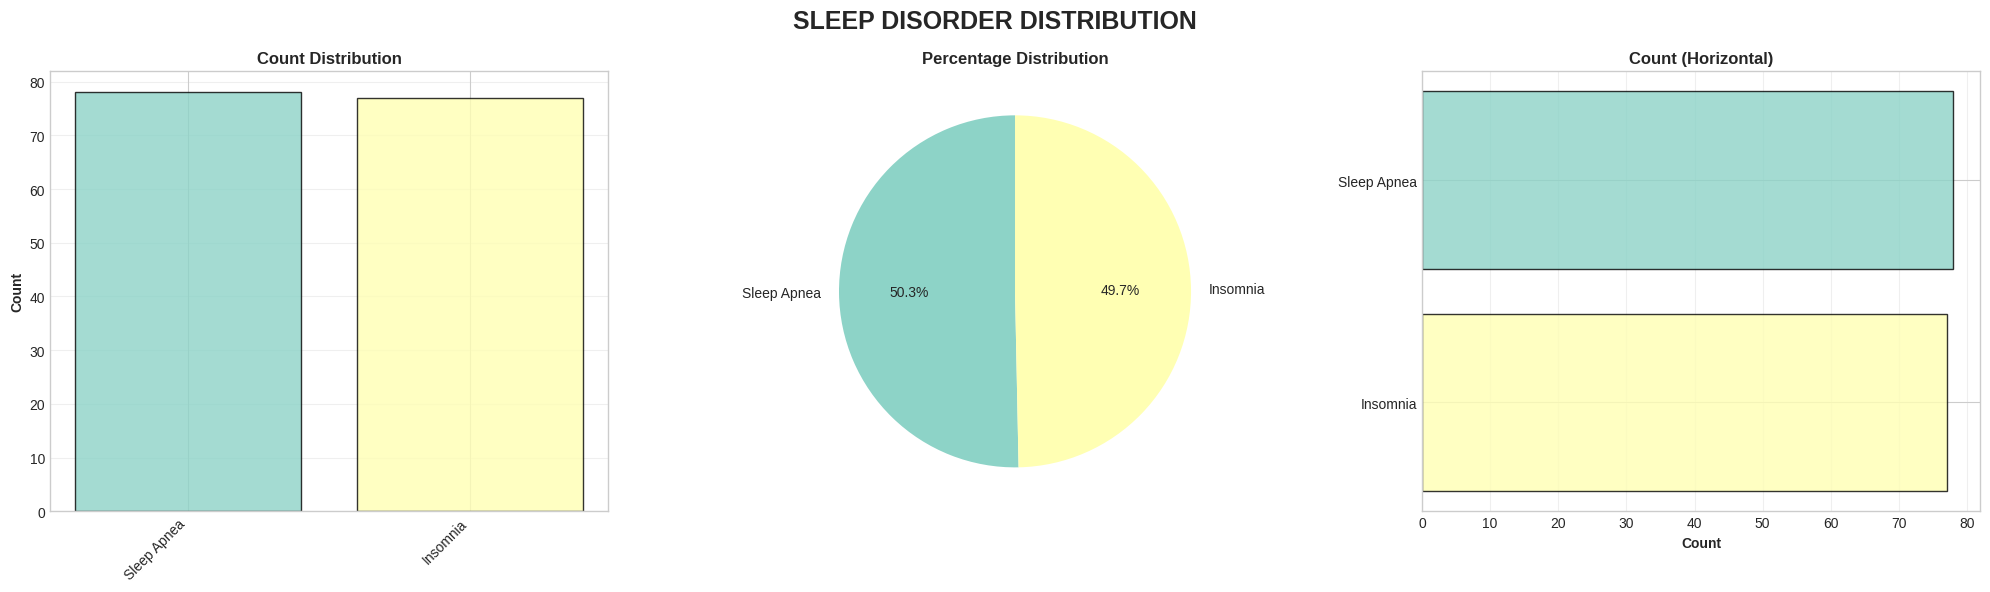

In [10]:
# Find target column
target_cols = [col for col in df.columns if 'disorder' in col.lower() or 'disease' in col.lower() or 'condition' in col.lower()]
if not target_cols:
    target_cols = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() < 10]

target_col = target_cols[0] if target_cols else df.columns[-1]

print('='*80)
print(f'TARGET: {target_col}')
print('='*80)
print('Distribution:')
print(df[target_col].value_counts())
print('\nPercentage:')
print(df[target_col].value_counts(normalize=True) * 100)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'{target_col.upper()} DISTRIBUTION', fontsize=18, fontweight='bold')

counts = df[target_col].value_counts()
colors = plt.cm.Set3(range(len(counts)))

# Count plot
axes[0].bar(range(len(counts)), counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Count Distribution', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90)
axes[1].set_title('Percentage Distribution', fontweight='bold')

# Horizontal bar
axes[2].barh(range(len(counts)), counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[2].set_yticks(range(len(counts)))
axes[2].set_yticklabels(counts.index)
axes[2].set_xlabel('Count', fontweight='bold')
axes[2].set_title('Count (Horizontal)', fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Sleep Duration & Quality Analysis

SLEEP METRICS

Sleep Duration: Sleep Duration
  Average: 7.13 hours
  Median: 7.20 hours
  Min: 5.80 hours
  Max: 8.50 hours

Sleep Quality: Quality of Sleep
  Average: 7.31/10
  Median: 7.00/10


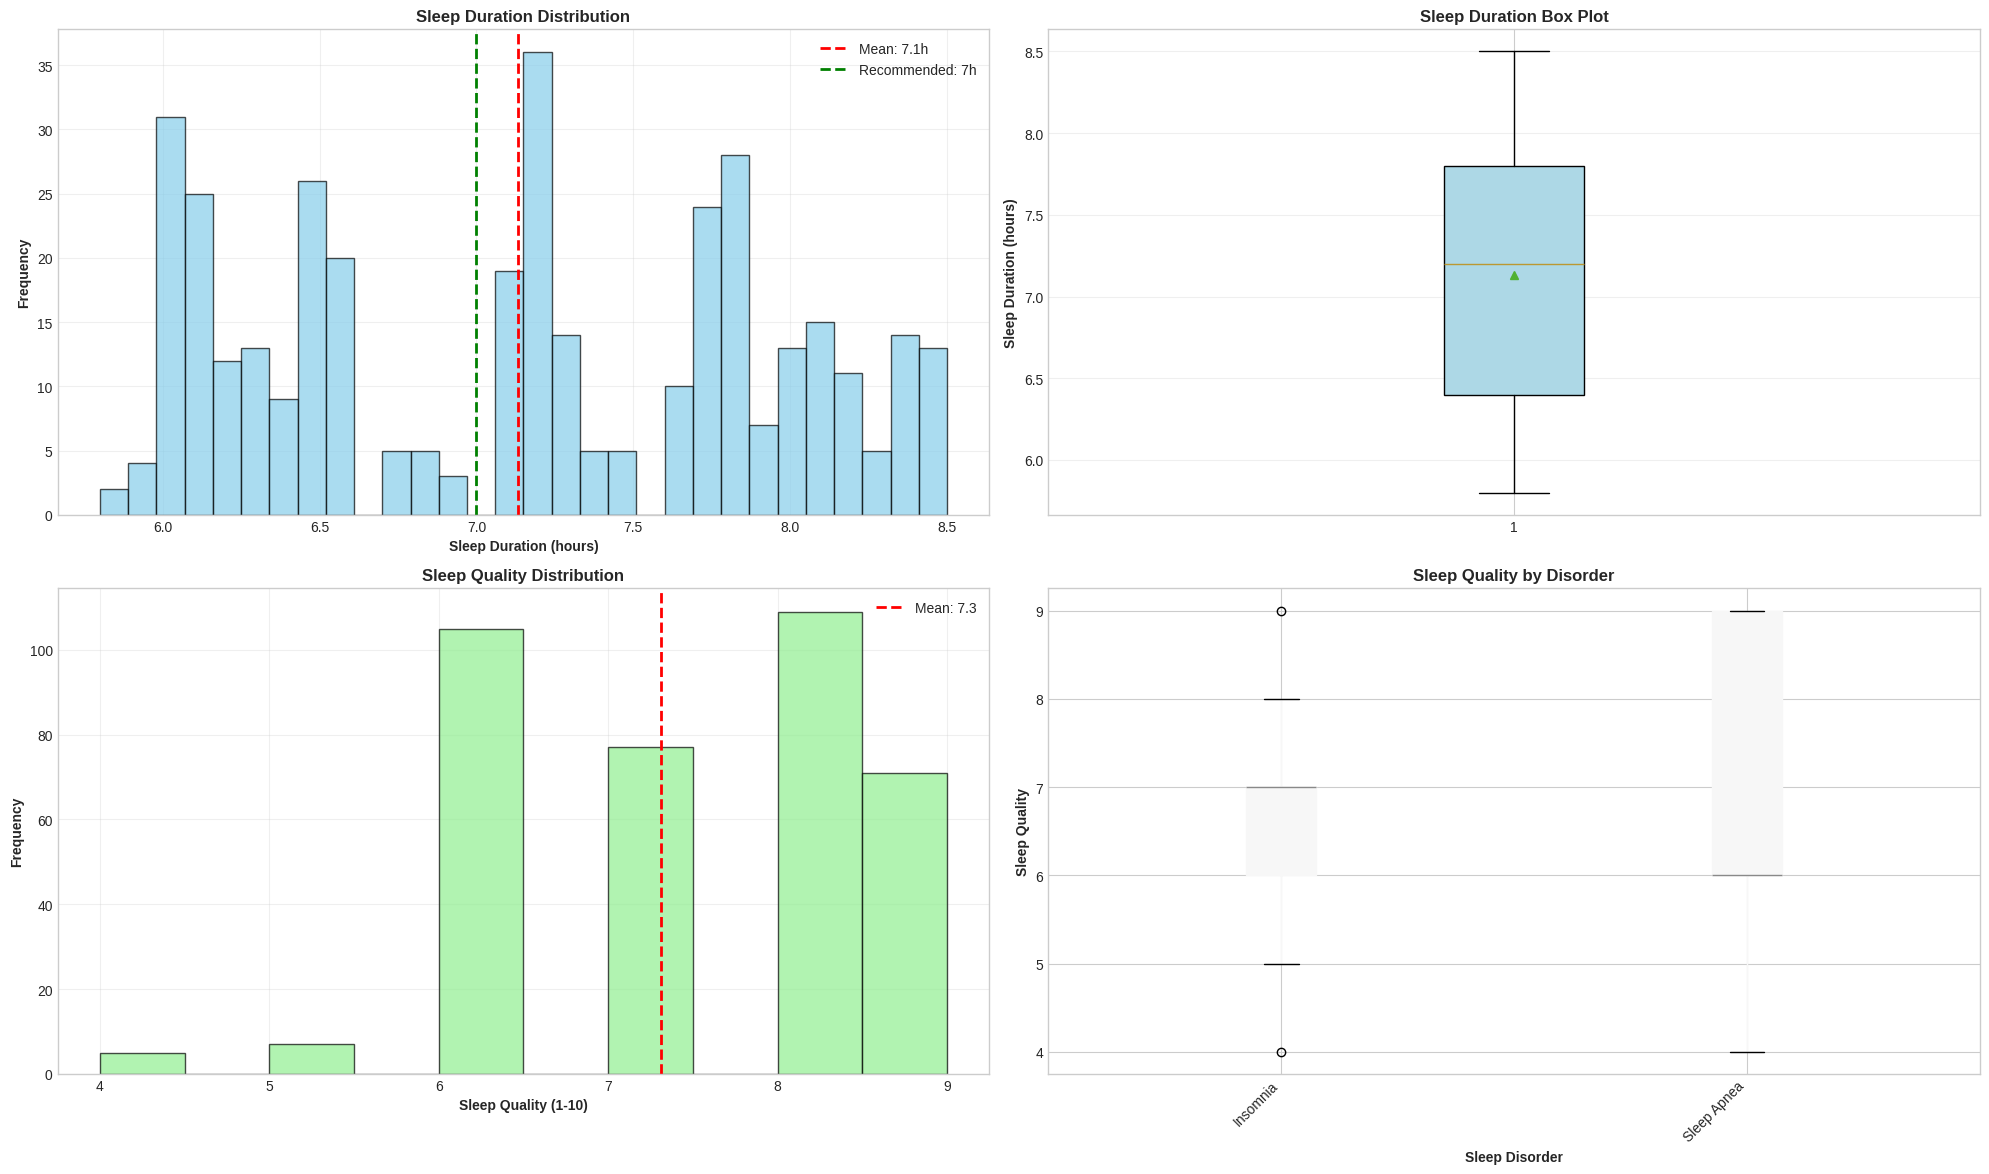

In [11]:
# Sleep columns
sleep_duration_cols = [col for col in df.columns if 'sleep' in col.lower() and 'duration' in col.lower()]
sleep_quality_cols = [col for col in df.columns if 'quality' in col.lower() and 'sleep' in col.lower()]

print('='*80)
print('SLEEP METRICS')
print('='*80)

if sleep_duration_cols:
    sleep_dur_col = sleep_duration_cols[0]
    print(f'\nSleep Duration: {sleep_dur_col}')
    print(f'  Average: {df[sleep_dur_col].mean():.2f} hours')
    print(f'  Median: {df[sleep_dur_col].median():.2f} hours')
    print(f'  Min: {df[sleep_dur_col].min():.2f} hours')
    print(f'  Max: {df[sleep_dur_col].max():.2f} hours')

if sleep_quality_cols:
    sleep_qual_col = sleep_quality_cols[0]
    print(f'\nSleep Quality: {sleep_qual_col}')
    print(f'  Average: {df[sleep_qual_col].mean():.2f}/10')
    print(f'  Median: {df[sleep_qual_col].median():.2f}/10')

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('SLEEP ANALYSIS', fontsize=18, fontweight='bold')

if sleep_duration_cols:
    # Duration histogram
    axes[0, 0].hist(df[sleep_dur_col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df[sleep_dur_col].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {df[sleep_dur_col].mean():.1f}h')
    axes[0, 0].axvline(7, color='green', linestyle='--', linewidth=2, label='Recommended: 7h')
    axes[0, 0].set_xlabel('Sleep Duration (hours)', fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].set_title('Sleep Duration Distribution', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Duration box plot
    bp = axes[0, 1].boxplot([df[sleep_dur_col].dropna()], patch_artist=True, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    axes[0, 1].set_ylabel('Sleep Duration (hours)', fontweight='bold')
    axes[0, 1].set_title('Sleep Duration Box Plot', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

if sleep_quality_cols:
    # Quality histogram
    axes[1, 0].hist(df[sleep_qual_col].dropna(), bins=10, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(df[sleep_qual_col].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {df[sleep_qual_col].mean():.1f}')
    axes[1, 0].set_xlabel('Sleep Quality (1-10)', fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontweight='bold')
    axes[1, 0].set_title('Sleep Quality Distribution', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Quality by disorder
    df.boxplot(column=sleep_qual_col, by=target_col, ax=axes[1, 1], patch_artist=True)
    axes[1, 1].set_xlabel(target_col, fontweight='bold')
    axes[1, 1].set_ylabel('Sleep Quality', fontweight='bold')
    axes[1, 1].set_title('Sleep Quality by Disorder', fontweight='bold')
    axes[1, 1].get_figure().suptitle('')
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Lifestyle Factors Analysis

LIFESTYLE FACTORS
Physical Activity: Physical Activity Level
  Average: 59.17

Stress Level: Stress Level
  Average: 5.39

Daily Steps: Daily Steps
  Average: 6,817


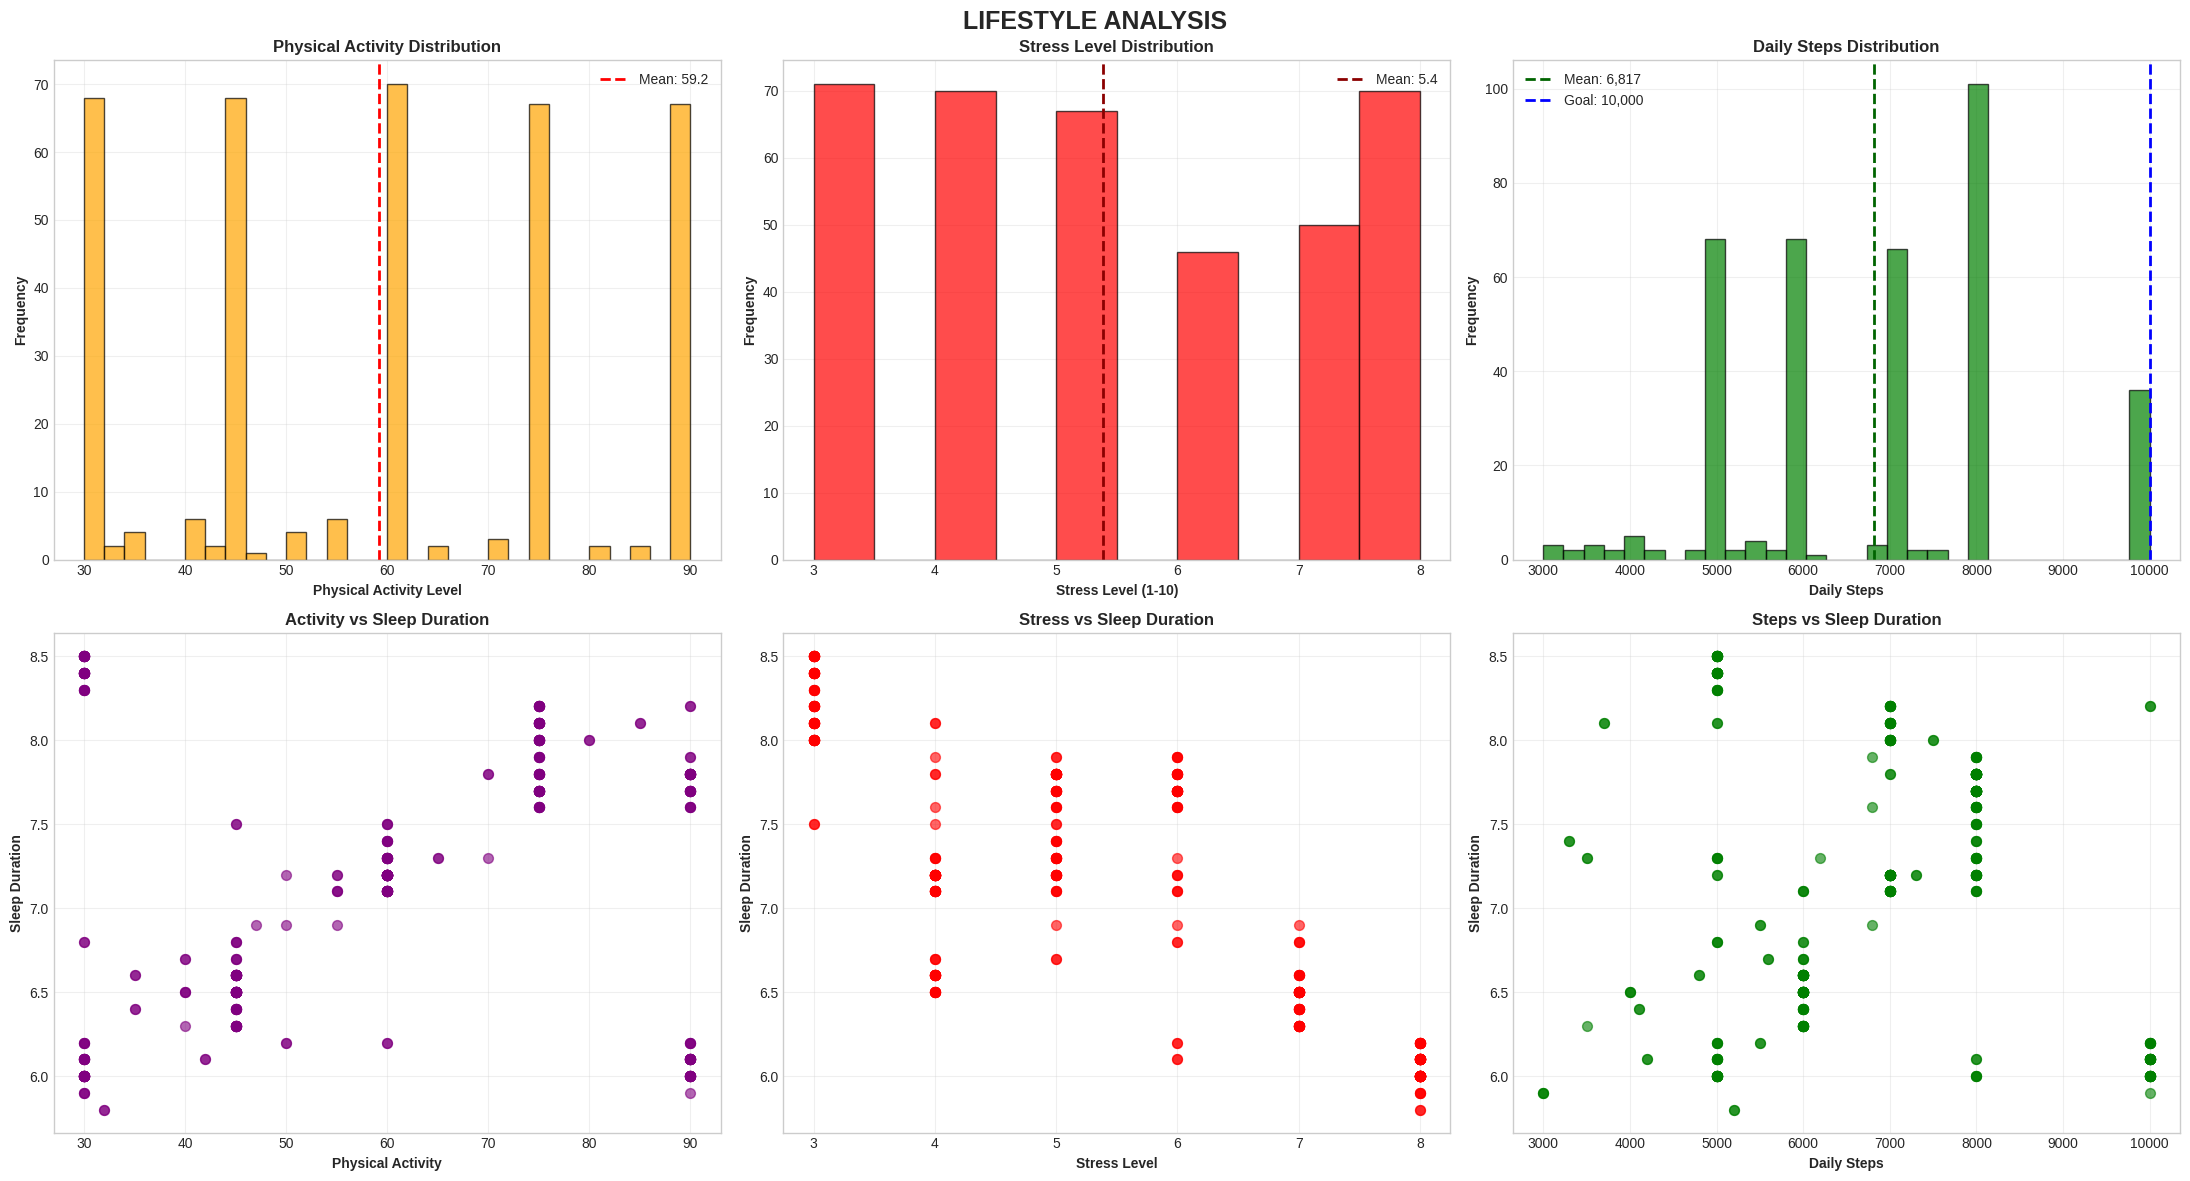

In [12]:
# Lifestyle columns
activity_cols = [col for col in df.columns if 'activity' in col.lower() or 'exercise' in col.lower() or 'physical' in col.lower()]
stress_cols = [col for col in df.columns if 'stress' in col.lower()]
steps_cols = [col for col in df.columns if 'step' in col.lower()]

print('='*80)
print('LIFESTYLE FACTORS')
print('='*80)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('LIFESTYLE ANALYSIS', fontsize=18, fontweight='bold')

plot_idx = 0

# Physical Activity
if activity_cols:
    activity_col = activity_cols[0]
    print(f'Physical Activity: {activity_col}')
    print(f'  Average: {df[activity_col].mean():.2f}')

    axes[0, 0].hist(df[activity_col].dropna(), bins=30, color='orange', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df[activity_col].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {df[activity_col].mean():.1f}')
    axes[0, 0].set_xlabel('Physical Activity Level', fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].set_title('Physical Activity Distribution', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

# Stress Level
if stress_cols:
    stress_col = stress_cols[0]
    print(f'\nStress Level: {stress_col}')
    print(f'  Average: {df[stress_col].mean():.2f}')

    axes[0, 1].hist(df[stress_col].dropna(), bins=10, color='red', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(df[stress_col].mean(), color='darkred', linestyle='--', linewidth=2,
                      label=f'Mean: {df[stress_col].mean():.1f}')
    axes[0, 1].set_xlabel('Stress Level (1-10)', fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontweight='bold')
    axes[0, 1].set_title('Stress Level Distribution', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

# Daily Steps
if steps_cols:
    steps_col = steps_cols[0]
    print(f'\nDaily Steps: {steps_col}')
    print(f'  Average: {df[steps_col].mean():,.0f}')

    axes[0, 2].hist(df[steps_col].dropna(), bins=30, color='green', edgecolor='black', alpha=0.7)
    axes[0, 2].axvline(df[steps_col].mean(), color='darkgreen', linestyle='--', linewidth=2,
                      label=f'Mean: {df[steps_col].mean():,.0f}')
    axes[0, 2].axvline(10000, color='blue', linestyle='--', linewidth=2, label='Goal: 10,000')
    axes[0, 2].set_xlabel('Daily Steps', fontweight='bold')
    axes[0, 2].set_ylabel('Frequency', fontweight='bold')
    axes[0, 2].set_title('Daily Steps Distribution', fontweight='bold')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3)

# Correlation plots
if sleep_duration_cols and activity_cols:
    axes[1, 0].scatter(df[activity_col], df[sleep_dur_col], alpha=0.6, s=50, color='purple')
    axes[1, 0].set_xlabel('Physical Activity', fontweight='bold')
    axes[1, 0].set_ylabel('Sleep Duration', fontweight='bold')
    axes[1, 0].set_title('Activity vs Sleep Duration', fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

if sleep_duration_cols and stress_cols:
    axes[1, 1].scatter(df[stress_col], df[sleep_dur_col], alpha=0.6, s=50, color='red')
    axes[1, 1].set_xlabel('Stress Level', fontweight='bold')
    axes[1, 1].set_ylabel('Sleep Duration', fontweight='bold')
    axes[1, 1].set_title('Stress vs Sleep Duration', fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

if sleep_duration_cols and steps_cols:
    axes[1, 2].scatter(df[steps_col], df[sleep_dur_col], alpha=0.6, s=50, color='green')
    axes[1, 2].set_xlabel('Daily Steps', fontweight='bold')
    axes[1, 2].set_ylabel('Sleep Duration', fontweight='bold')
    axes[1, 2].set_title('Steps vs Sleep Duration', fontweight='bold')
    axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Health Metrics Analysis

HEALTH METRICS
BMI: BMI Category
Heart Rate: Heart Rate


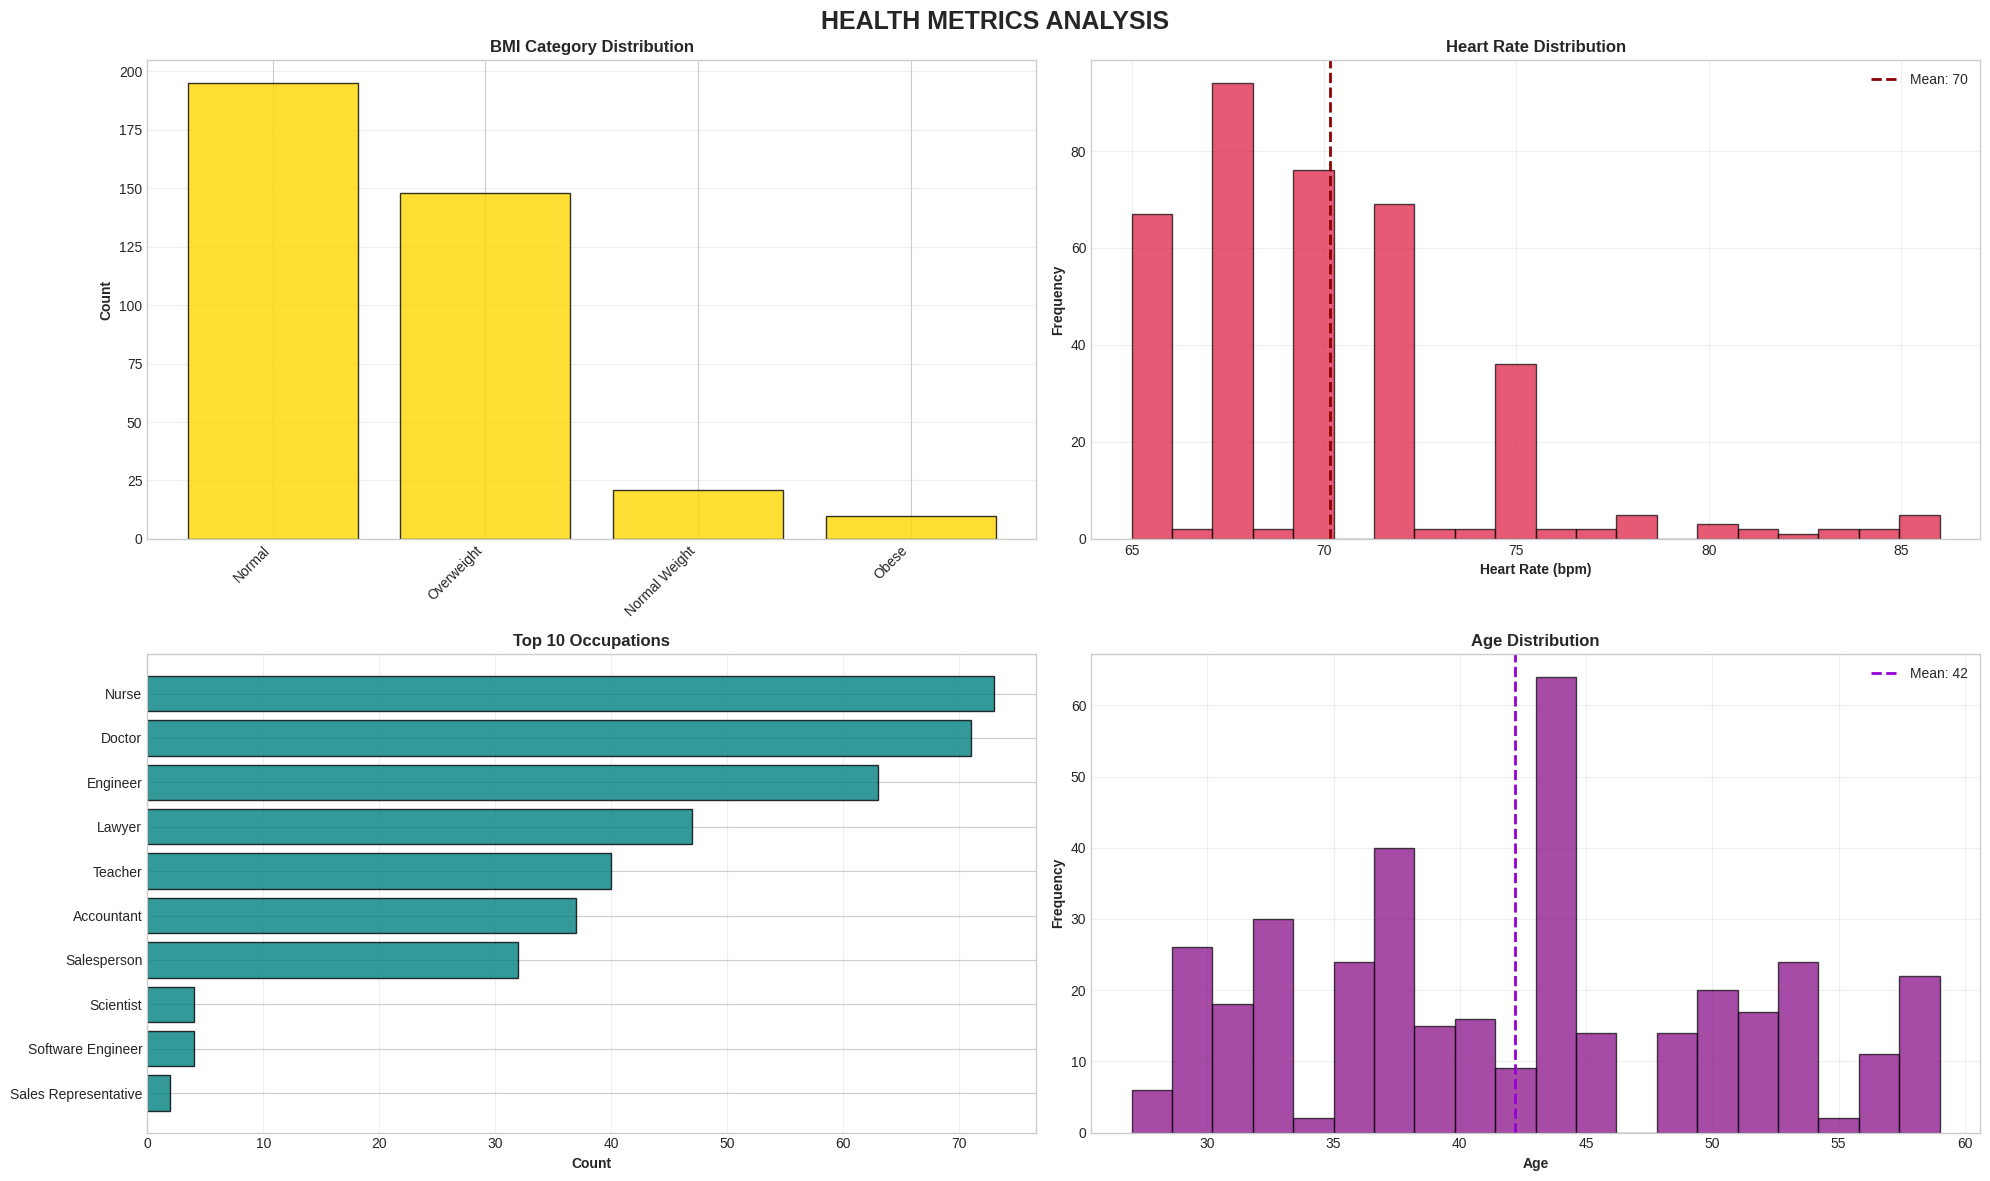

In [13]:
# Health metrics
bmi_cols = [col for col in df.columns if 'bmi' in col.lower()]
bp_cols = [col for col in df.columns if 'blood' in col.lower() or 'pressure' in col.lower()]
hr_cols = [col for col in df.columns if 'heart' in col.lower() or 'rate' in col.lower()]

print('='*80)
print('HEALTH METRICS')
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('HEALTH METRICS ANALYSIS', fontsize=18, fontweight='bold')

# BMI
if bmi_cols:
    bmi_col = bmi_cols[0]
    print(f'BMI: {bmi_col}')
    if df[bmi_col].dtype == 'object':
        bmi_counts = df[bmi_col].value_counts()
        axes[0, 0].bar(range(len(bmi_counts)), bmi_counts.values,
                      color='gold', edgecolor='black', alpha=0.8)
        axes[0, 0].set_xticks(range(len(bmi_counts)))
        axes[0, 0].set_xticklabels(bmi_counts.index, rotation=45, ha='right')
        axes[0, 0].set_ylabel('Count', fontweight='bold')
        axes[0, 0].set_title('BMI Category Distribution', fontweight='bold')
        axes[0, 0].grid(axis='y', alpha=0.3)
    else:
        axes[0, 0].hist(df[bmi_col].dropna(), bins=20, color='gold', edgecolor='black', alpha=0.7)
        axes[0, 0].set_xlabel('BMI', fontweight='bold')
        axes[0, 0].set_ylabel('Frequency', fontweight='bold')
        axes[0, 0].set_title('BMI Distribution', fontweight='bold')
        axes[0, 0].grid(alpha=0.3)

# Heart Rate
if hr_cols:
    hr_col = hr_cols[0]
    print(f'Heart Rate: {hr_col}')
    if df[hr_col].dtype in [np.float64, np.int64]:
        axes[0, 1].hist(df[hr_col].dropna(), bins=20, color='crimson', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(df[hr_col].mean(), color='darkred', linestyle='--', linewidth=2,
                          label=f'Mean: {df[hr_col].mean():.0f}')
        axes[0, 1].set_xlabel('Heart Rate (bpm)', fontweight='bold')
        axes[0, 1].set_ylabel('Frequency', fontweight='bold')
        axes[0, 1].set_title('Heart Rate Distribution', fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

# Occupation distribution
occupation_cols = [col for col in df.columns if 'occupation' in col.lower() or 'job' in col.lower()]
if occupation_cols:
    occupation_col = occupation_cols[0]
    occ_counts = df[occupation_col].value_counts().head(10)
    axes[1, 0].barh(range(len(occ_counts)), occ_counts.values,
                   color='teal', edgecolor='black', alpha=0.8)
    axes[1, 0].set_yticks(range(len(occ_counts)))
    axes[1, 0].set_yticklabels(occ_counts.index)
    axes[1, 0].set_xlabel('Count', fontweight='bold')
    axes[1, 0].set_title('Top 10 Occupations', fontweight='bold')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)

# Age distribution
age_cols = [col for col in df.columns if 'age' in col.lower()]
if age_cols:
    age_col = age_cols[0]
    axes[1, 1].hist(df[age_col].dropna(), bins=20, color='purple', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(df[age_col].mean(), color='darkviolet', linestyle='--', linewidth=2,
                      label=f'Mean: {df[age_col].mean():.0f}')
    axes[1, 1].set_xlabel('Age', fontweight='bold')
    axes[1, 1].set_ylabel('Frequency', fontweight='bold')
    axes[1, 1].set_title('Age Distribution', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Correlation Analysis

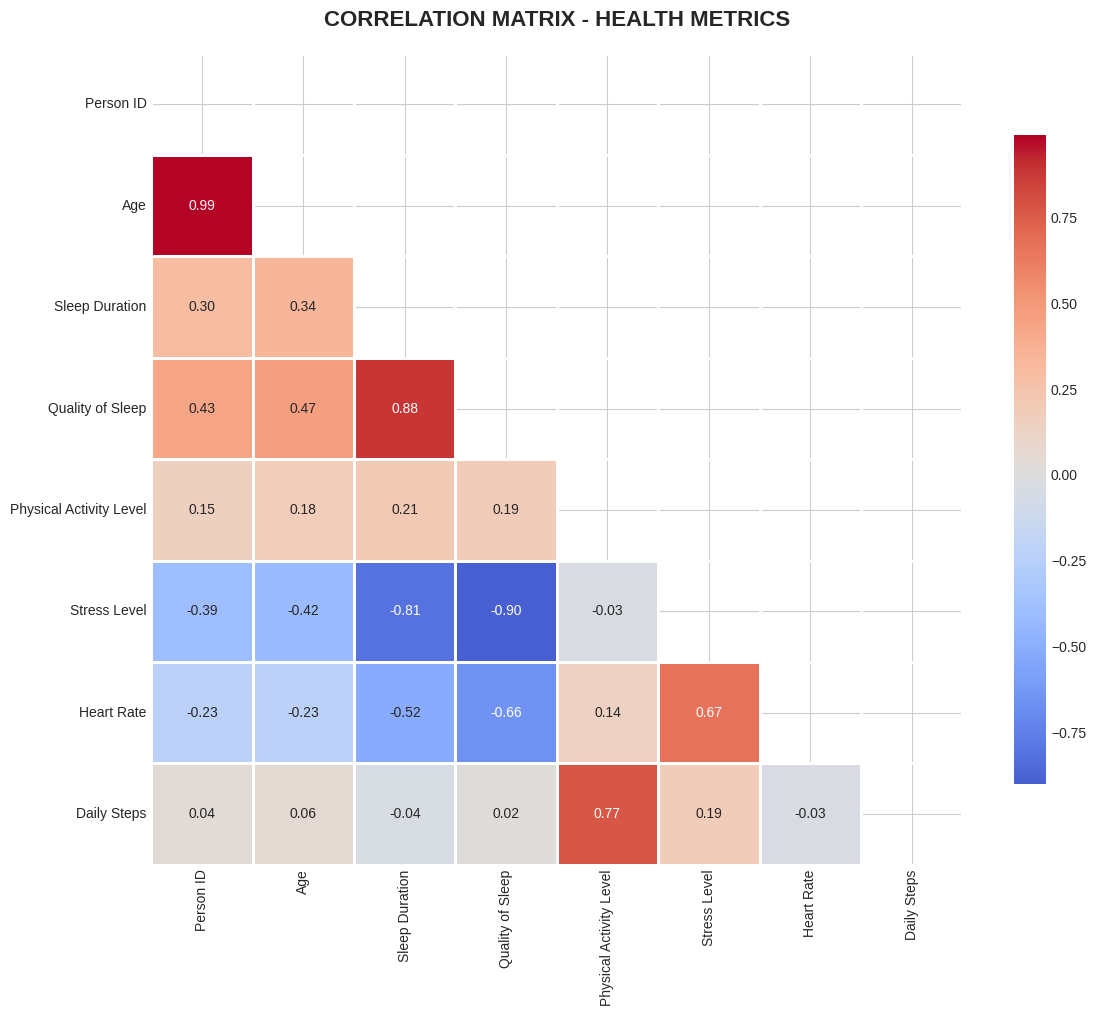

In [14]:
# Numeric correlation
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 1:
    corr = numeric_df.corr()

    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
               cmap='coolwarm', center=0, linewidths=1,
               cbar_kws={'shrink': 0.8}, square=True)
    plt.title('CORRELATION MATRIX - HEALTH METRICS', fontweight='bold', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

## 4. FEATURE ENGINEERING

In [15]:
print('='*80)
print('FEATURE ENGINEERING - HEALTH SPECIFIC')
print('='*80)

df_clean = df.copy()

# 1. Sleep quality categories
if sleep_quality_cols:
    df_clean['sleep_quality_category'] = pd.cut(df_clean[sleep_qual_col],
                                                bins=[0, 5, 7, 10],
                                                labels=['Poor', 'Fair', 'Good'])
    print('sleep_quality_category: Created')

# 2. Sleep duration categories
if sleep_duration_cols:
    df_clean['sleep_duration_category'] = pd.cut(df_clean[sleep_dur_col],
                                                 bins=[0, 6, 7, 9, 12],
                                                 labels=['Insufficient', 'Adequate', 'Optimal', 'Excessive'])
    print('sleep_duration_category: Created')

# 3. Stress categories
if stress_cols:
    df_clean['stress_category'] = pd.cut(df_clean[stress_col],
                                         bins=[0, 3, 6, 10],
                                         labels=['Low', 'Moderate', 'High'])
    print('stress_category: Created')

# 4. Activity categories
if activity_cols:
    df_clean['activity_category'] = pd.cut(df_clean[activity_col],
                                           bins=[0, 30, 60, 120],
                                           labels=['Sedentary', 'Moderate', 'Active'])
    print('activity_category: Created')

# 5. Steps goal achievement
if steps_cols:
    df_clean['meets_step_goal'] = (df_clean[steps_col] >= 10000).astype(int)
    print('meets_step_goal: Created')

# 6. Age groups
if age_cols:
    df_clean['age_group'] = pd.cut(df_clean[age_col],
                                   bins=[0, 30, 45, 60, 100],
                                   labels=['Young', 'MiddleAge', 'Senior', 'Elderly'])
    print('age_group: Created')

print(f'\nTotal columns: {len(df_clean.columns)}')
print('='*80)

FEATURE ENGINEERING - HEALTH SPECIFIC
sleep_quality_category: Created
sleep_duration_category: Created
stress_category: Created
activity_category: Created
meets_step_goal: Created
age_group: Created

Total columns: 19


In [16]:
# Handle missing values
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include=['object', 'category']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Remove duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{duplicates} duplicates removed')

print(f'Clean dataset: {len(df_clean):,} rows')

Clean dataset: 374 rows


## 5. MODEL PREPARATION

In [17]:
print('='*80)
print('MODEL PREPARATION - CLASSIFICATION')
print('='*80)

# Target encoding
print(f'Original target values: {df_clean[target_col].unique()}')
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_clean[target_col])
print(f'Encoded target values: {np.unique(y)}')

# Features
X = df_clean.drop(columns=[target_col]).copy()

# Drop ID columns
id_cols = [col for col in X.columns if 'id' in col.lower() or 'person' in col.lower()]
if id_cols:
    X = X.drop(columns=id_cols)
    print(f'Dropped ID columns: {id_cols}')

# Encoding
print('\nEncoding features...')
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f'  Binary: {col}')
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)
        print(f'  One-hot: {col}')

print(f'\nFeatures: {X.shape[1]}')
print(f'Samples: {len(X):,}')
print(f'Target classes: {len(np.unique(y))}')
print('='*80)

MODEL PREPARATION - CLASSIFICATION
Original target values: ['Sleep Apnea' 'Insomnia']
Encoded target values: [0 1]
Dropped ID columns: ['Person ID']

Encoding features...
  Binary: Gender
  One-hot: Occupation
  One-hot: BMI Category
  One-hot: Blood Pressure
  One-hot: sleep_quality_category
  One-hot: sleep_duration_category
  One-hot: stress_category
  One-hot: activity_category
  One-hot: age_group

Features: 58
Samples: 374
Target classes: 2


In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split:')
print(f'  Train: {len(X_train):,}')
print(f'  Test: {len(X_test):,}')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('\nScaling: StandardScaler')

# SMOTE (if imbalanced)
if len(np.unique(y_train)) > 1:
    class_counts = np.bincount(y_train)
    if max(class_counts) / min(class_counts) > 1.5:
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
        print(f'SMOTE: {len(X_train):,} -> {len(X_train_smote):,}')
    else:
        X_train_smote = X_train_scaled
        y_train_smote = y_train
        print('No SMOTE needed (balanced)')
else:
    X_train_smote = X_train_scaled
    y_train_smote = y_train

Train-Test Split:
  Train: 299
  Test: 75

Scaling: StandardScaler
SMOTE: 299 -> 474


## 6. ML MODELS - 15+ WITH NEURAL NETWORK!

### OZEL: Neural Network (MLP) - SVM YERINE!

In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True),  # SVM YERINE!
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis(),
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42)
}

print('='*80)
print(f'{len(models)} MODELS - NEURAL NETWORK INSTEAD OF SVM!')
print('='*80)
for name in models.keys():
    marker = ' <<< NEURAL NETWORK!' if 'Neural' in name else ''
    print(f'  - {name}{marker}')
print('='*80)

15 MODELS - NEURAL NETWORK INSTEAD OF SVM!
  - Logistic Regression
  - Ridge Classifier
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - Neural Network (MLP) <<< NEURAL NETWORK!
  - KNN
  - Naive Bayes
  - AdaBoost
  - Extra Trees
  - LDA
  - Bagging


In [21]:
results = {}

print('='*80)
print('MODEL TRAINING')
print('='*80)

for name, model in models.items():
    print(f'\n{name}...')

    try:
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled) if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # ROC-AUC for multi-class
        roc_auc = None
        if y_pred_proba is not None:
            try:
                if len(np.unique(y_test)) == 2:
                    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
                else:
                    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            except:
                pass

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc,
            'predictions': y_pred,
            'pred_proba': y_pred_proba,
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        marker = ' <<< NEURAL NET!' if 'Neural' in name else ''
        print(f'  SUCCESS! Acc: {accuracy:.4f}, F1: {f1:.4f}{marker}')

    except Exception as e:
        print(f'  ERROR: {str(e)}')
        continue

print('\n' + '='*80)
print(f'TRAINING COMPLETE! {len(results)}/{len(models)} models')
print('='*80)

MODEL TRAINING

Logistic Regression...
  SUCCESS! Acc: 0.9733, F1: 0.9739

Ridge Classifier...
  SUCCESS! Acc: 0.9600, F1: 0.9613

Decision Tree...
  SUCCESS! Acc: 0.9733, F1: 0.9739

Random Forest...
  SUCCESS! Acc: 0.9600, F1: 0.9605

Gradient Boosting...
  SUCCESS! Acc: 0.9733, F1: 0.9739

XGBoost...
  SUCCESS! Acc: 0.9600, F1: 0.9613

LightGBM...
  SUCCESS! Acc: 0.9467, F1: 0.9479

CatBoost...
  SUCCESS! Acc: 0.9600, F1: 0.9605

Neural Network (MLP)...
  SUCCESS! Acc: 0.9733, F1: 0.9739 <<< NEURAL NET!

KNN...
  SUCCESS! Acc: 0.9067, F1: 0.9113

Naive Bayes...
  SUCCESS! Acc: 0.6000, F1: 0.6333

AdaBoost...
  SUCCESS! Acc: 0.9600, F1: 0.9605

Extra Trees...
  SUCCESS! Acc: 0.9600, F1: 0.9605

LDA...
  SUCCESS! Acc: 0.9467, F1: 0.9489

Bagging...
  SUCCESS! Acc: 0.9733, F1: 0.9739

TRAINING COMPLETE! 15/15 models


## 7. RESULTS - COMPREHENSIVE COMPARISON

In [22]:
if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
        'Precision': [results[m]['Precision'] for m in results.keys()],
        'Recall': [results[m]['Recall'] for m in results.keys()],
        'F1 Score': [results[m]['F1_Score'] for m in results.keys()],
        'ROC-AUC': [results[m]['ROC_AUC'] if results[m]['ROC_AUC'] else 0 for m in results.keys()]
    }).sort_values('F1 Score', ascending=False).reset_index(drop=True)

    print('='*100)
    print('MODEL PERFORMANCE COMPARISON')
    print('='*100)
    print(results_df.to_string(index=False))
    print('='*100)

    best_model = results_df.iloc[0]['Model']
    print(f'\nBEST MODEL: {best_model}')
    print(f'  F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'  Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    # Neural Network performance
    nn_row = results_df[results_df['Model'].str.contains('Neural')]
    if not nn_row.empty:
        nn_rank = nn_row.index[0] + 1
        print(f'\nNEURAL NETWORK PERFORMANCE:')
        print(f'  Rank: #{nn_rank}/{len(results_df)}')
        print(f'  F1 Score: {nn_row.iloc[0]["F1 Score"]:.4f}')
        print(f'  Accuracy: {nn_row.iloc[0]["Accuracy"]:.4f}')
else:
    print('No results!')

MODEL PERFORMANCE COMPARISON
               Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
 Logistic Regression      0.97       0.98    0.97      0.97     0.98
       Decision Tree      0.97       0.98    0.97      0.97     0.98
   Gradient Boosting      0.97       0.98    0.97      0.97     0.98
             Bagging      0.97       0.98    0.97      0.97     0.99
Neural Network (MLP)      0.97       0.98    0.97      0.97     1.00
    Ridge Classifier      0.96       0.97    0.96      0.96     0.00
             XGBoost      0.96       0.97    0.96      0.96     0.99
         Extra Trees      0.96       0.96    0.96      0.96     0.98
       Random Forest      0.96       0.96    0.96      0.96     0.99
            AdaBoost      0.96       0.96    0.96      0.96     0.99
            CatBoost      0.96       0.96    0.96      0.96     0.99
                 LDA      0.95       0.96    0.95      0.95     0.97
            LightGBM      0.95       0.95    0.95      0.95     0.99
     

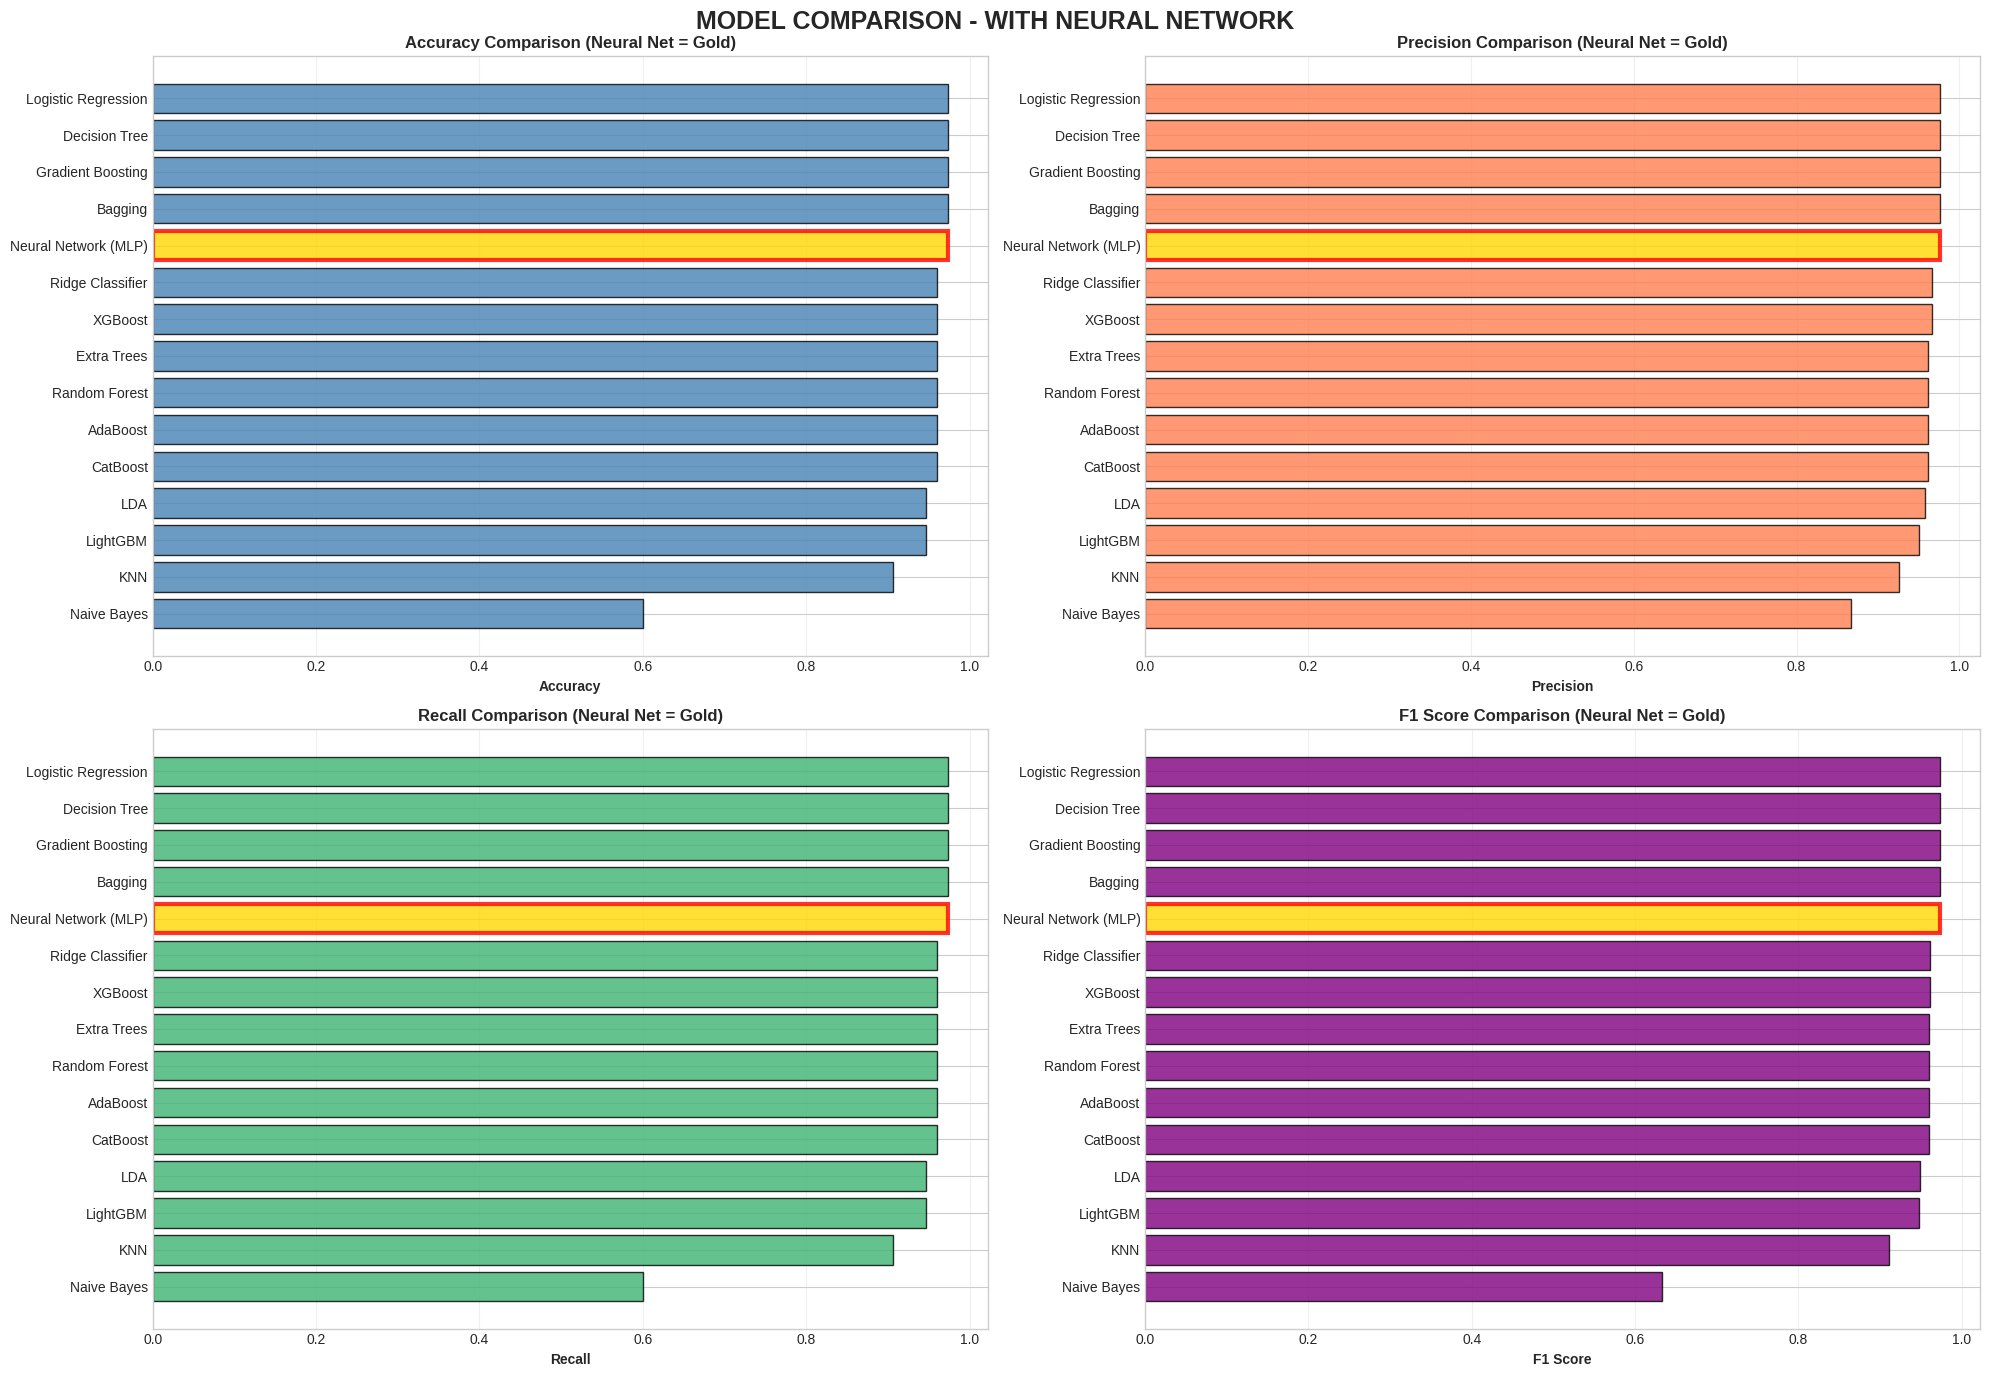

In [23]:
# Visual comparison
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('MODEL COMPARISON - WITH NEURAL NETWORK', fontsize=18, fontweight='bold')

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    colors_list = ['steelblue', 'coral', 'mediumseagreen', 'purple']

    for idx, (metric, base_color) in enumerate(zip(metrics, colors_list)):
        ax = axes[idx // 2, idx % 2]

        # Color Neural Network differently
        colors = []
        for model_name in results_df['Model']:
            if 'Neural' in model_name:
                colors.append('gold')  # Neural Network = GOLD!
            else:
                colors.append(base_color)

        bars = ax.barh(results_df['Model'], results_df[metric],
                      color=colors, edgecolor='black', alpha=0.8)

        # Highlight Neural Network
        for i, model_name in enumerate(results_df['Model']):
            if 'Neural' in model_name:
                bars[i].set_edgecolor('red')
                bars[i].set_linewidth(3)

        ax.set_xlabel(metric, fontweight='bold')
        ax.set_title(f'{metric} Comparison (Neural Net = Gold)', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

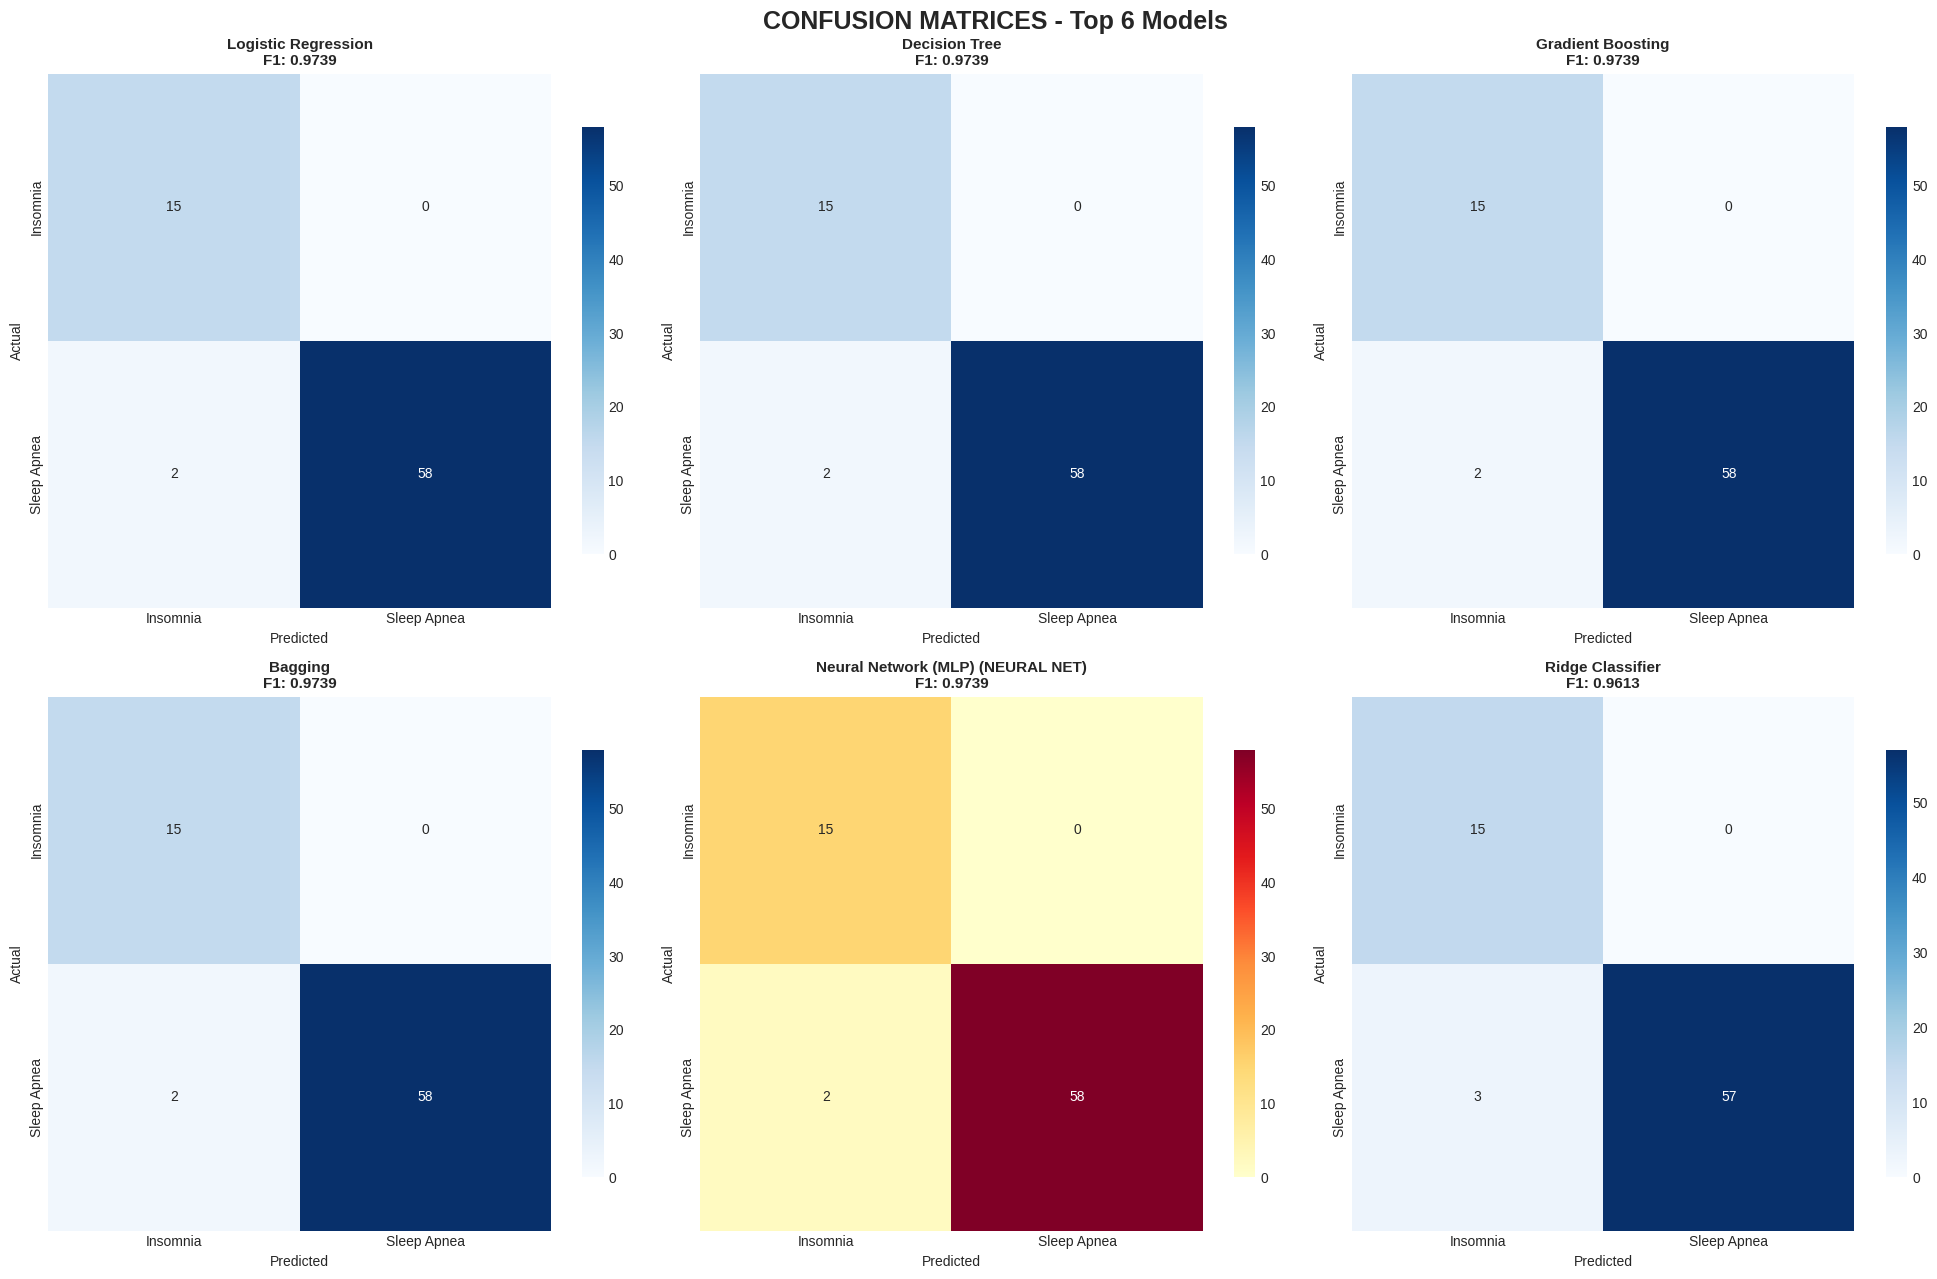

In [24]:
# Confusion matrices (top 6)
if results and len(results) >= 6:
    top_6 = results_df.head(6)['Model'].tolist()

    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    fig.suptitle('CONFUSION MATRICES - Top 6 Models', fontsize=18, fontweight='bold')

    for idx, model_name in enumerate(top_6):
        ax = axes[idx // 3, idx % 3]
        cm = results[model_name]['confusion_matrix']

        labels = target_encoder.classes_

        # Special color for Neural Network
        cmap = 'YlOrRd' if 'Neural' in model_name else 'Blues'

        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                   xticklabels=labels, yticklabels=labels,
                   cbar_kws={'shrink': 0.8})

        title_suffix = ' (NEURAL NET)' if 'Neural' in model_name else ''
        ax.set_title(f'{model_name}{title_suffix}\nF1: {results[model_name]["F1_Score"]:.4f}',
                    fontweight='bold', fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

## 8. FINAL RESULTS & HEALTH INSIGHTS

In [25]:
print('='*100)
print('SLEEP HEALTH & LIFESTYLE - FINAL RESULTS')
print('='*100)

print('\n1. DATASET:')
print(f'   Total: {len(df):,}')
print(f'   Features: {X.shape[1]}')
print(f'   Sleep Disorders: {len(target_encoder.classes_)}')

if results:
    print(f'\n2. BEST MODEL:')
    print(f'   Model: {best_model}')
    print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    print(f'\n3. NEURAL NETWORK PERFORMANCE:')
    if not nn_row.empty:
        print(f'   Rank: #{nn_rank}/{len(results_df)}')
        print(f'   F1 Score: {nn_row.iloc[0]["F1 Score"]:.4f}')
        print(f'   Accuracy: {nn_row.iloc[0]["Accuracy"]:.4f}')
        print(f'   Status: SVM REPLACEMENT SUCCESS!')

    print(f'\n4. TOP 5 MODELS:')
    for idx, row in results_df.head(5).iterrows():
        marker = ' *** NEURAL NET' if 'Neural' in row['Model'] else ''
        print(f'   {idx+1}. {row["Model"]:25} F1: {row["F1 Score"]:.4f}{marker}')

print(f'\n5. HEALTH INSIGHTS:')
if sleep_duration_cols:
    print(f'   - Average Sleep: {df[sleep_dur_col].mean():.1f} hours')
    below_7 = (df[sleep_dur_col] < 7).sum()
    print(f'   - Insufficient Sleep: {below_7:,} ({below_7/len(df)*100:.1f}%)')
if stress_cols:
    print(f'   - Average Stress: {df[stress_col].mean():.1f}/10')
if steps_cols:
    meets_goal = (df[steps_col] >= 10000).sum()
    print(f'   - Meets Step Goal: {meets_goal:,} ({meets_goal/len(df)*100:.1f}%)')

print(f'\n6. RECOMMENDATIONS:')
print(f'   - Use {best_model} for sleep disorder prediction')
print(f'   - Neural Network (MLP) successfully replaced SVM')
print(f'   - Monitor sleep duration, stress, activity levels')
print(f'   - Target 7-9 hours sleep, <10,000 steps daily')
print(f'   - Manage stress for better sleep quality')

print('\n' + '='*100)
print('SLEEP HEALTH ANALYSIS COMPLETE!')
print('='*100)

SLEEP HEALTH & LIFESTYLE - FINAL RESULTS

1. DATASET:
   Total: 374
   Features: 58
   Sleep Disorders: 2

2. BEST MODEL:
   Model: Logistic Regression
   F1 Score: 0.9739
   Accuracy: 0.9733

3. NEURAL NETWORK PERFORMANCE:
   Rank: #5/15
   F1 Score: 0.9739
   Accuracy: 0.9733
   Status: SVM REPLACEMENT SUCCESS!

4. TOP 5 MODELS:
   1. Logistic Regression       F1: 0.9739
   2. Decision Tree             F1: 0.9739
   3. Gradient Boosting         F1: 0.9739
   4. Bagging                   F1: 0.9739
   5. Neural Network (MLP)      F1: 0.9739 *** NEURAL NET

5. HEALTH INSIGHTS:
   - Average Sleep: 7.1 hours
   - Insufficient Sleep: 155 (41.4%)
   - Average Stress: 5.4/10
   - Meets Step Goal: 36 (9.6%)

6. RECOMMENDATIONS:
   - Use Logistic Regression for sleep disorder prediction
   - Neural Network (MLP) successfully replaced SVM
   - Monitor sleep duration, stress, activity levels
   - Target 7-9 hours sleep, <10,000 steps daily
   - Manage stress for better sleep quality

SLEEP HEAL